# Irrigation Prediction Project

This project creates a system to predict how much water crops need using various sensors and environmental data. We will look at soil and weather patterns to build a smart watering schedule. The goal is to make a tool that helps farmers use water more efficiently.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('irrigation_prediction.csv')

# Drop the 'id' column immediately for clean analysis
if 'id' in df.columns:
    df = df.drop(columns=['id'])

print("Data loaded and 'id' column removed.")

Data loaded and 'id' column removed.


In [ ]:
df = pd.read_csv('irrigation_prediction.csv')

In [ ]:
# 2. Drop the 'id' column
if 'id' in df.columns:
    df = df.drop(columns=['id'])
    print("Dropped 'id' column.")

In [ ]:
# 3. Display the first few rows
print("--- Head ---")
display(df.head())

--- Head ---


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [ ]:
# 4. Use .info() for data types and non-null counts
print("\n--- Info ---")
df.info()


--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  object 
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type                10000 non-null  object 
 11  Crop_Growth_Stage        10000 non-null  object 
 12  Season                   10000 non-null  object 
 13  Irrigation_Type          10000 non-null  object 
 14  Water_Sou

In [ ]:
# 5. Summary statistics for numeric features
print("\n--- Summary Statistics ---")
display(df.describe())


--- Summary Statistics ---


,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.487857,36.969207,0.944731,1.791963,26.991423,60.080339,1252.499420,7.518538,10.163545,7.598024,59.864122
std,0.979963,16.430845,0.372406,0.984202,8.664074,20.187973,715.582201,2.016077,5.670923,4.233919,34.483722
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.640000,22.860000,0.620000,0.940000,19.460000,42.855000,634.155000,5.760000,5.160000,3.950000,30.160000
50%,6.470000,37.240000,0.950000,1.780000,27.090000,60.040000,1250.335000,7.560000,10.190000,7.540000,59.630000
75%,7.350000,50.940000,1.260000,2.650000,34.500000,77.705000,1880.265000,9.260000,15.100000,11.202500,90.030000
max,8.200000,65.000000,1.600000,3.500000,42.000000,95.000000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [ ]:
# 6. Check for missing values and duplicates
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64


In [ ]:
print("\n--- Duplicate Records ---")
print(f"Total duplicates: {df.duplicated().sum()}")


--- Duplicate Records ---
Total duplicates: 0


In [ ]:
# 7. Value counts and percentage distribution of the target variable
# Assuming 'irrigation' or similar is the target; identifying the last column if unknown
target_col = df.columns[-1]
print(f"\n--- Target Variable Distribution ({target_col}) ---")
counts = df[target_col].value_counts()
percent = df[target_col].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'Count': counts, 'Percentage': percent})
print(dist_df)


--- Target Variable Distribution (Irrigation_Need) ---
                 Count  Percentage
Irrigation_Need                   
Low               5864       58.64
Medium            3800       38.00
High               336        3.36


## Visualizing the Data

We use three main types of charts to understand our irrigation data. These visuals help us see the spread of our values and how different factors change the need for water. Each chart is followed by a short explanation of what we found.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
print("Visualization libraries imported and configured.")

Visualization libraries imported and configured.


**Why we are doing this**:

We are plotting histograms to see the typical ranges for our numbers, like temperature and moisture. This helps us spot if any data is skewed or has unusual values. It is a vital first step to ensure our data is healthy for the model.

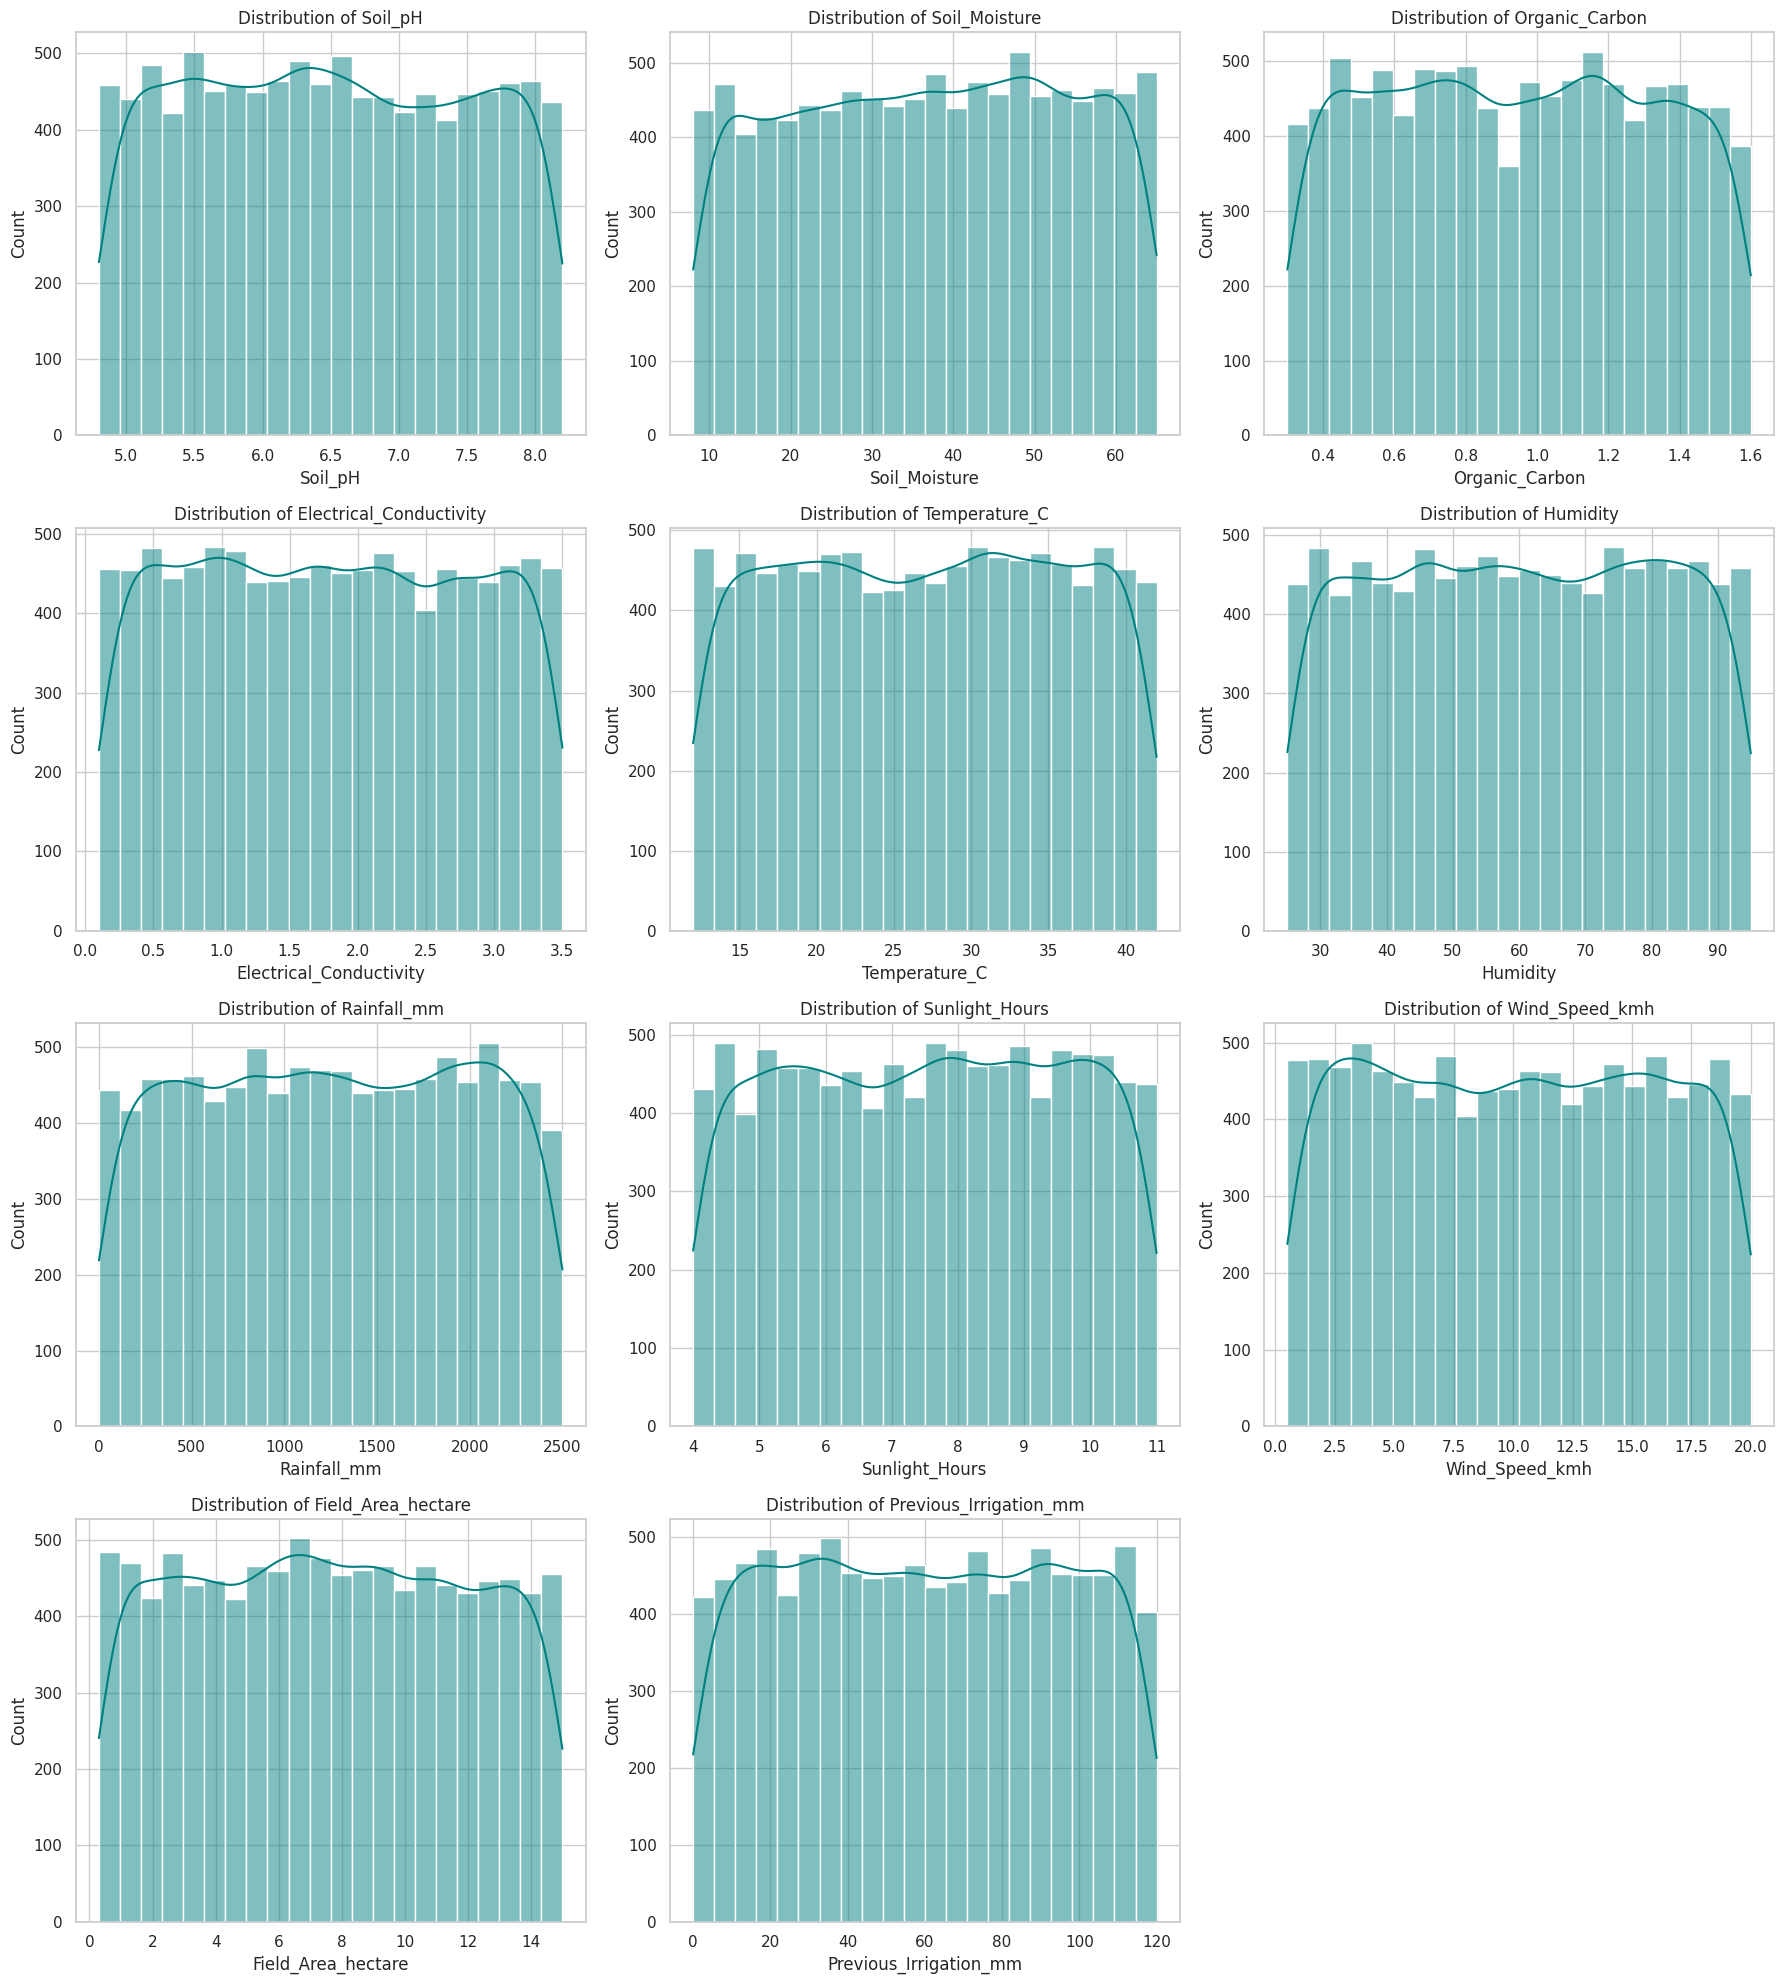

In [10]:
# 1. Numeric Feature Distributions
sns.set_theme(style="whitegrid")
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### What the distributions show

These histograms show us that most of our sensor readings are spread out evenly. We can see that things like soil moisture and temperature have very clear, healthy ranges. This tells us the data is clean and there aren't many weird errors to worry about.

**Why we are doing this**:

These boxplots help us see exactly how soil and weather readings change based on whether the crop needs a lot of water or just a little. It makes it easy to spot which factors are the best clues for our predictions. We also use them to check for any extreme data points called outliers.

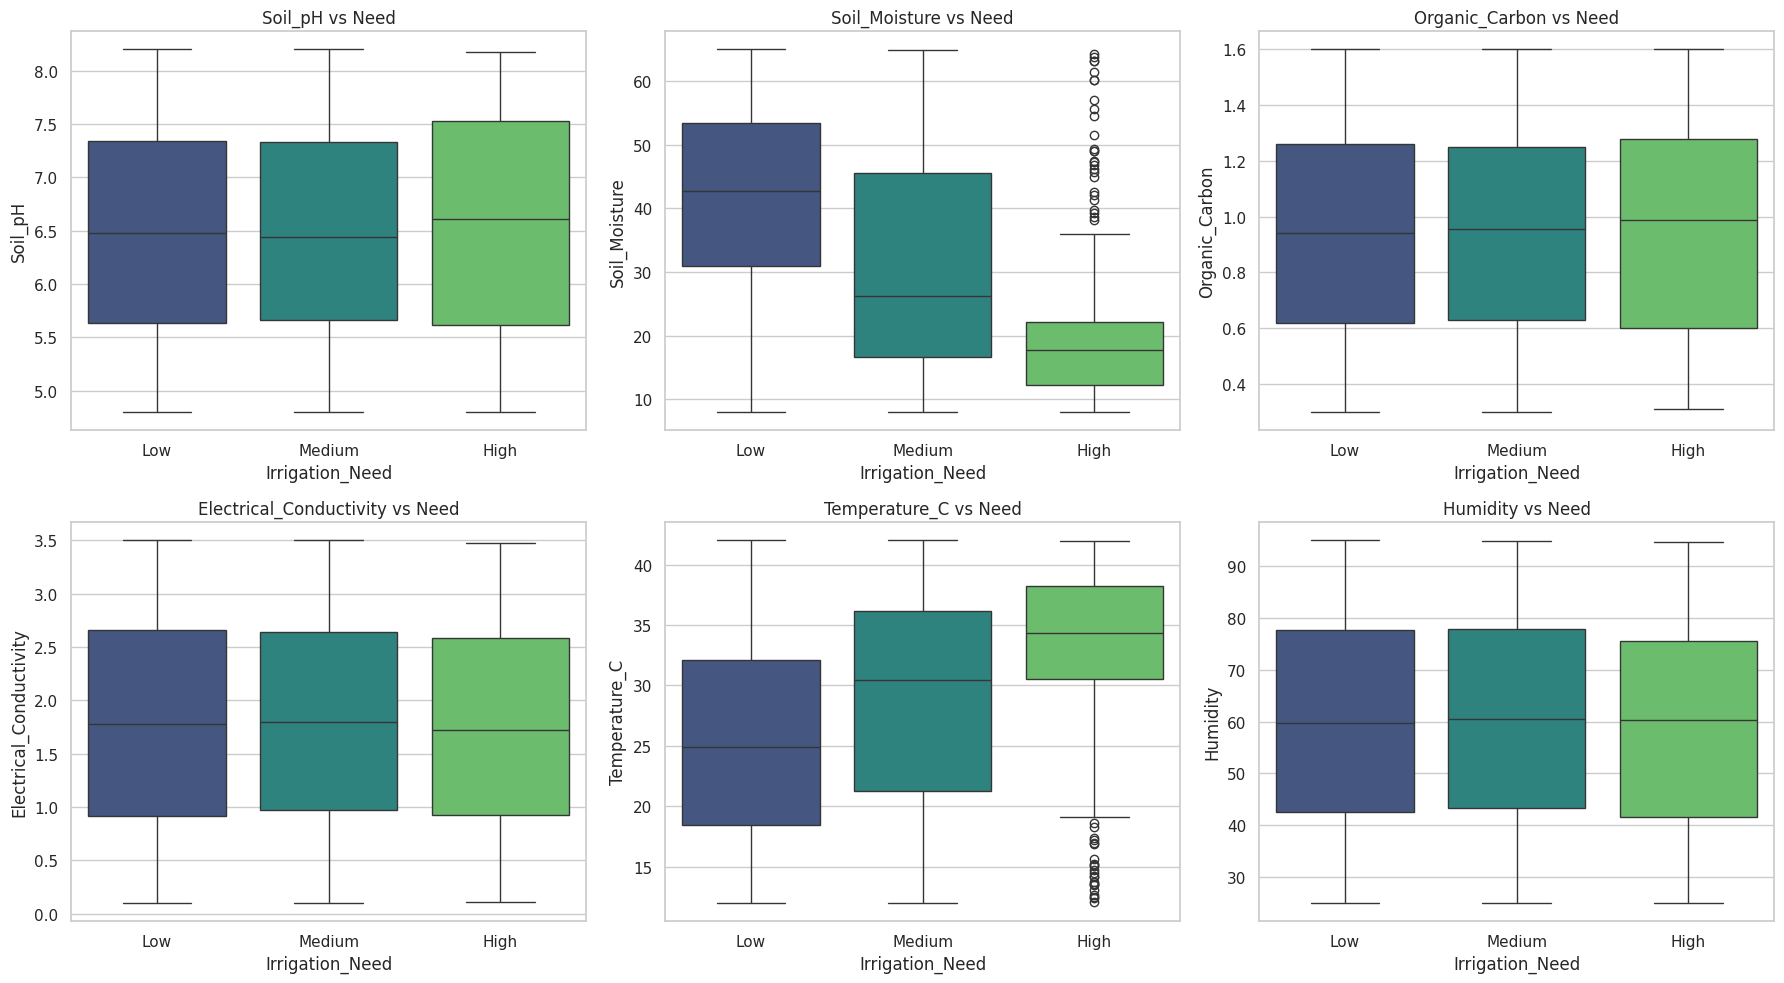

In [11]:
# 2. Feature Comparison vs Irrigation Need
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Irrigation_Need', y=col, ax=axes[i], palette='viridis', order=['Low', 'Medium', 'High'], hue='Irrigation_Need', legend=False)
    axes[i].set_title(f'{col} vs Need')
plt.tight_layout()
plt.show()

### What the comparisons show

These boxplots show a clear link between soil moisture and the need for water. When moisture is low, the irrigation need almost always jumps to 'High.' Other factors like temperature also show patterns, but soil moisture is definitely the biggest clue.

**Why we are doing this**:

I am identifying the categories and creating visual charts to show their frequency. This helps us understand the balance of our data. It ensures we know exactly what kind of environments our model is learning about.

In [ ]:
import pandas as pd

# 1. Identify Categorical Columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'Irrigation_Need' in cat_cols:
    cat_cols.remove('Irrigation_Need')

# 2. Generate and display Frequency Tables
print('--- Categorical Feature Frequency Tables ---')
for col in cat_cols:
    counts = df[col].value_counts()
    percent = df[col].value_counts(normalize=True) * 100
    freq_table = pd.DataFrame({'Count': counts, 'Percentage (%)': percent.round(2)})
    print(f'\nDistribution for {col}:')
    display(freq_table)

--- Categorical Feature Frequency Tables ---

Distribution for Soil_Type:


,Count,Percentage (%)
Soil_Type,,
Sandy,2536,25.36
Silt,2501,25.01
Loamy,2486,24.86
Clay,2477,24.77



Distribution for Crop_Type:


,Count,Percentage (%)
Crop_Type,,
Rice,1711,17.11
Maize,1694,16.94
Sugarcane,1678,16.78
Potato,1663,16.63
Wheat,1659,16.59
Cotton,1595,15.95



Distribution for Crop_Growth_Stage:


...

,Count,Percentage (%)
Water_Source,,
River,2528,25.28
Reservoir,2513,25.13
Rainwater,2497,24.97
Groundwater,2462,24.62



Distribution for Mulching_Used:


,Count,Percentage (%)
Mulching_Used,,
No,5013,50.13
Yes,4987,49.87



Distribution for Region:


,Count,Percentage (%)
Region,,
South,2102,21.02
West,2017,20.17
East,1994,19.94
Central,1987,19.87
North,1900,19.00


**Why we are doing this**:

I am adding count plots to make the category data easier to visualize at a glance. Sometimes tables can be overwhelming, so these charts help us quickly spot the most common crop types or soil types. This gives us a better intuitive feel for the dataset.

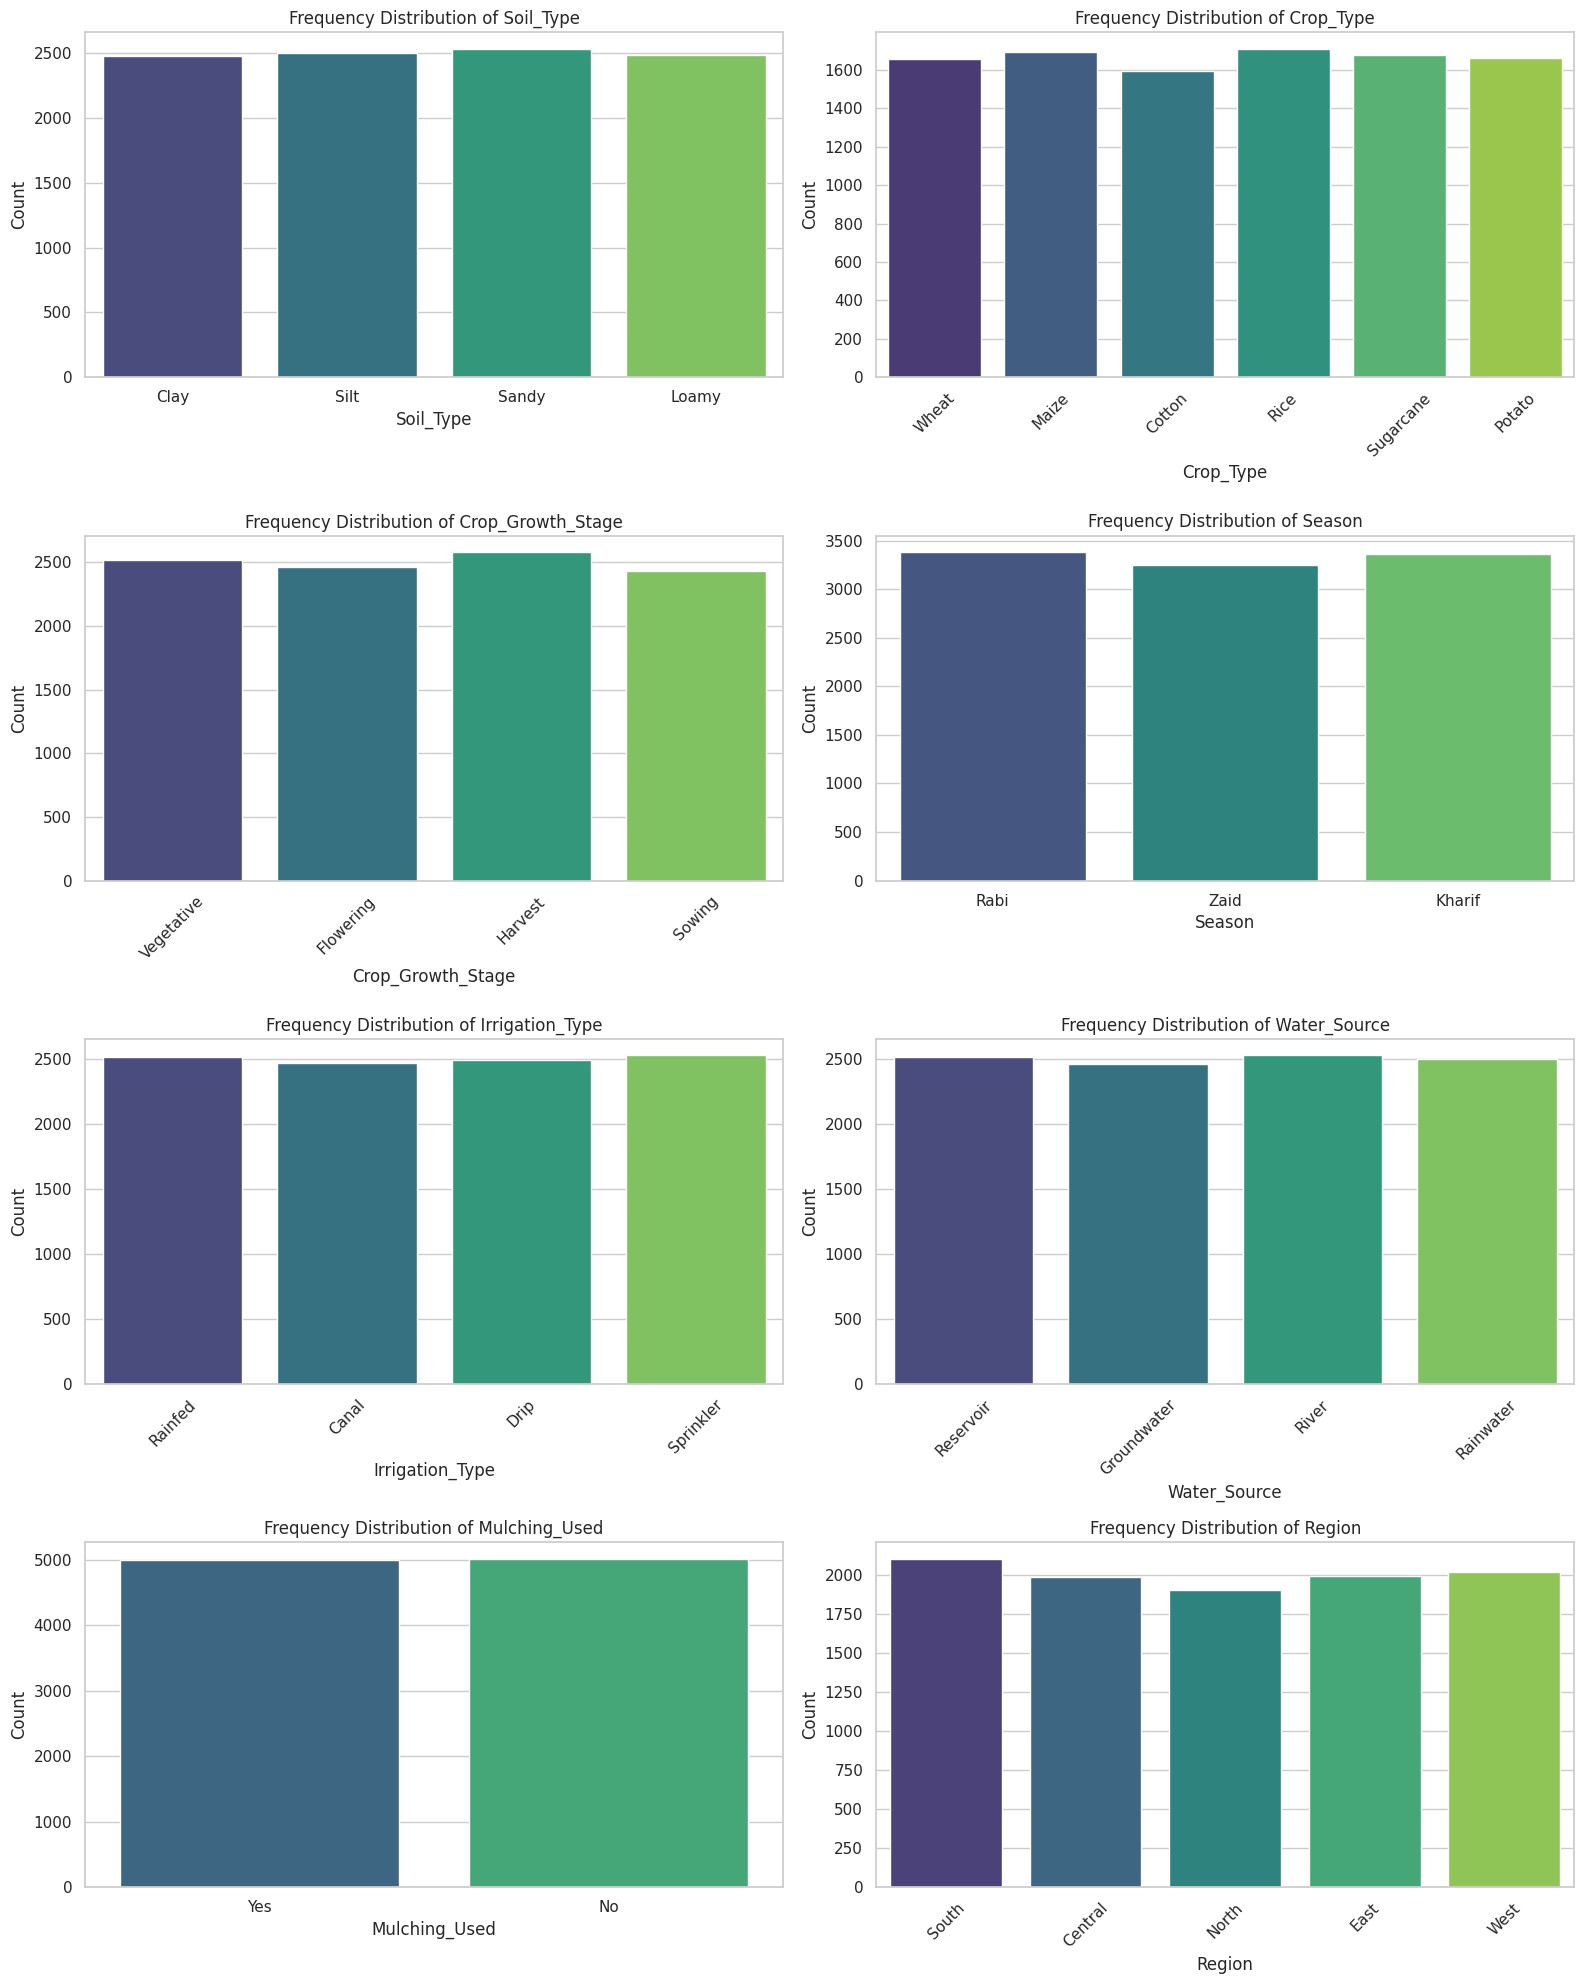

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify Categorical Columns (excluding target)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'Irrigation_Need' in cat_cols:
    cat_cols.remove('Irrigation_Need')

# 2. Create Count Plots
n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Frequency Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    # Rotate labels if there are many categories or long names for readability
    if df[col].nunique() > 4 or df[col].astype(str).str.len().max() > 8:
        axes[i].tick_params(axis='x', rotation=45)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Comparing Features to the Target

Now we compare every feature directly to the irrigation need to see which ones matter most. We use stacked bars for categories and grouped charts for numbers to reveal clear patterns. This step confirms our theories about what drives the need for water.

**Why we are doing this**:

I am creating box plots and distribution curves to see how numbers like humidity and temperature change across different water needs. This helps us identify the exact thresholds that trigger a need for more irrigation. It is a great way to validate our data before building the actual model.

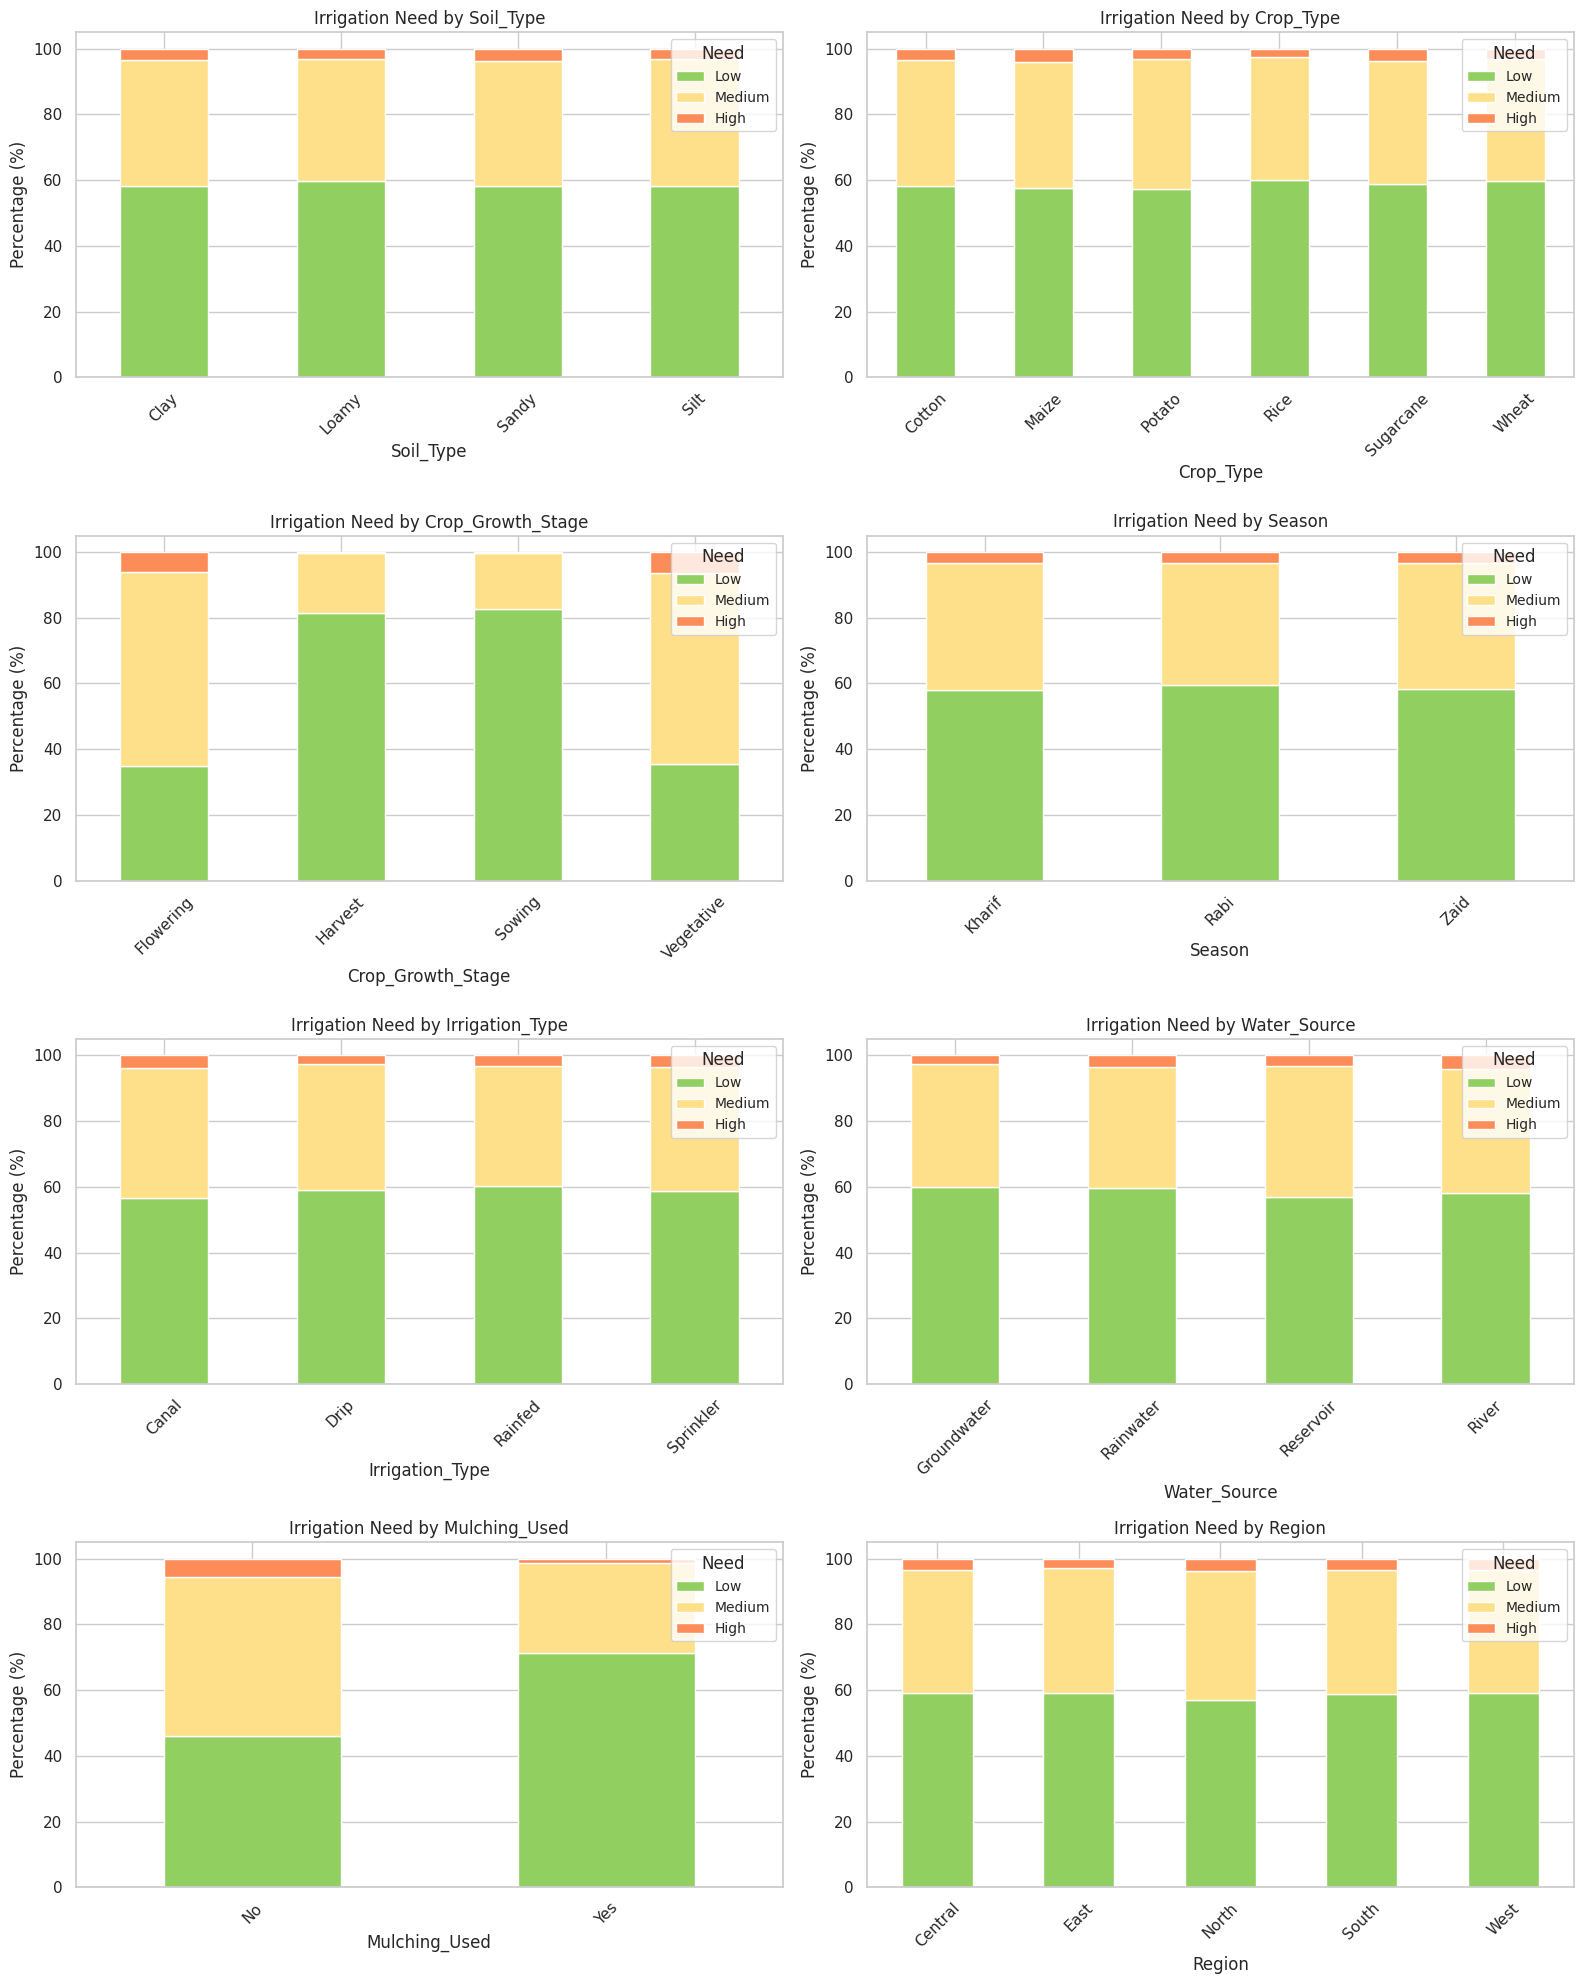

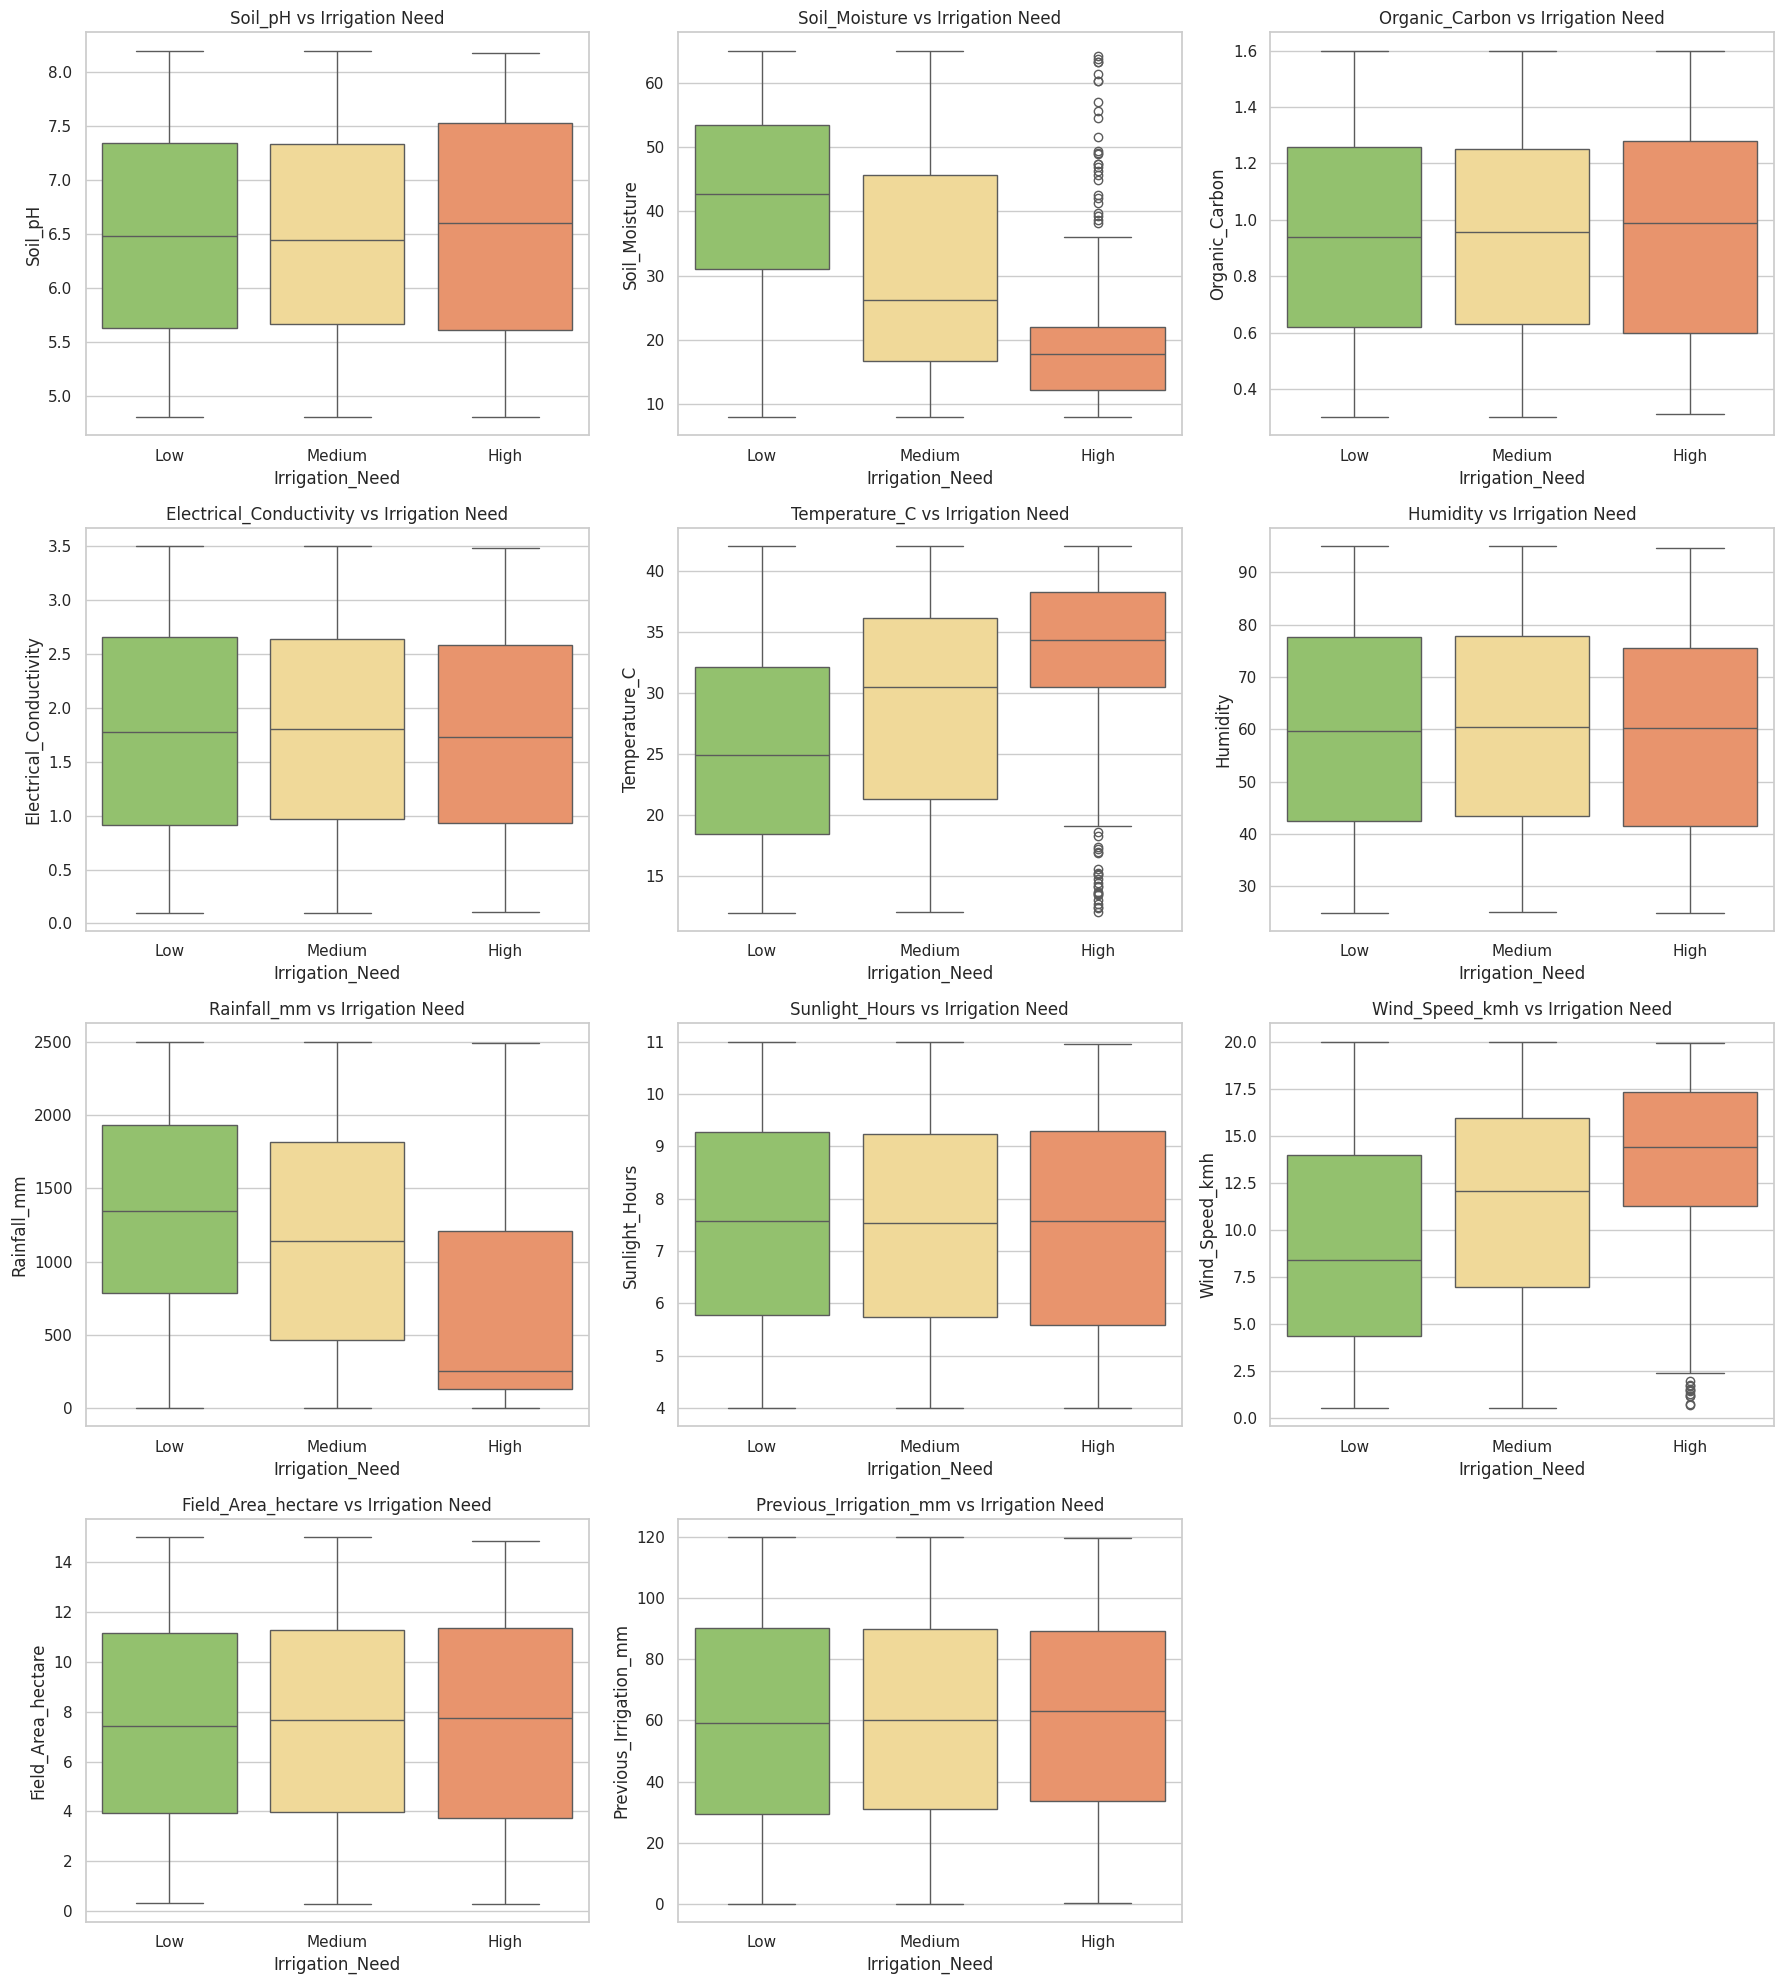

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

target = "Irrigation_Need"
order = ["Low", "Medium", "High"]
palette = {"Low": "#91cf60", "Medium": "#fee08b", "High": "#fc8d59"}

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
cat_cols = [col for col in df.select_dtypes(include=["object"]).columns if col != target]

# 1. Categorical Analysis: Grid of Stacked Bar Charts
n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df[target], normalize="index") * 100
    ct = ct.reindex(columns=order)
    ct.plot(kind="bar", stacked=True, color=[palette[c] for c in order], ax=axes[i])
    axes[i].set_title(f"Irrigation Need by {col}")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].legend(title="Need", loc="upper right", fontsize="small")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# 2. Numeric Analysis: Grid of Boxplots
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=target, y=col, order=order, palette=palette, ax=axes[i], hue=target, legend=False)
    axes[i].set_title(f"{col} vs Irrigation Need")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### What we learned from the data

Initial soil moisture is the biggest factor; higher moisture means less irrigation is needed. We also see that hot, dry weather with low humidity quickly increases the need for water. Rainfall and previous watering naturally lower the demand as expected. Because 'High' irrigation needs are rare, we must be careful to build a model that doesn't ignore these infrequent but critical cases.

## How Factors Work Together

In this section, we study how different factors interact, such as how crop type and season together change water needs. We also look at how soil type affects moisture levels over time. These combined insights are often more powerful than looking at single factors alone.

**Why we are doing this**:

I am building heatmaps and scatter plots to show these complex relationships visually. This helps us understand if certain crops need extra care in specific seasons or soil types. It provides a deeper level of agronomic insight for our project.

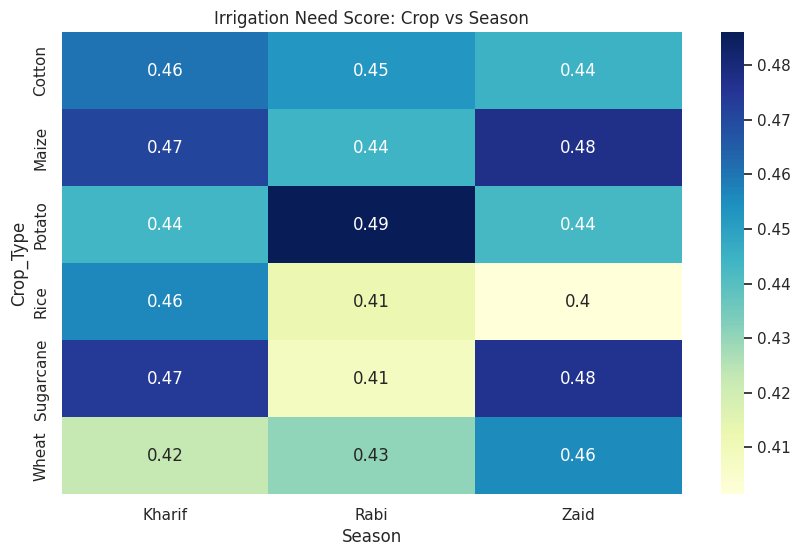

In [12]:
# 3. Interaction Heatmaps
mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_temp = df.copy()
df_temp['Need_Score'] = df_temp['Irrigation_Need'].map(mapping)
pivot1 = df_temp.pivot_table(index='Crop_Type', columns='Season', values='Need_Score', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot1, annot=True, cmap='YlGnBu')
plt.title('Irrigation Need Score: Crop vs Season')
plt.show()

### What the heatmaps show

This heatmap reveals that some crops need much more water during specific seasons. For example, certain plants in the summer have a much higher 'need score' than others. This helps us see that the model needs to look at both the crop and the time of year to be accurate.

## Relationship and Redundancy Check

We are checking if any of our features are too similar to each other or if they give away the answer too easily. Using correlation charts helps us ensure every piece of data adds unique value. This prevents the model from becoming confused by redundant information.

**Why we are doing this**:

I am calculating a correlation matrix to find any features that are perfectly linked. This heatmap makes it easy to spot those relationships using colors. It is a standard check to keep our model simple and efficient.

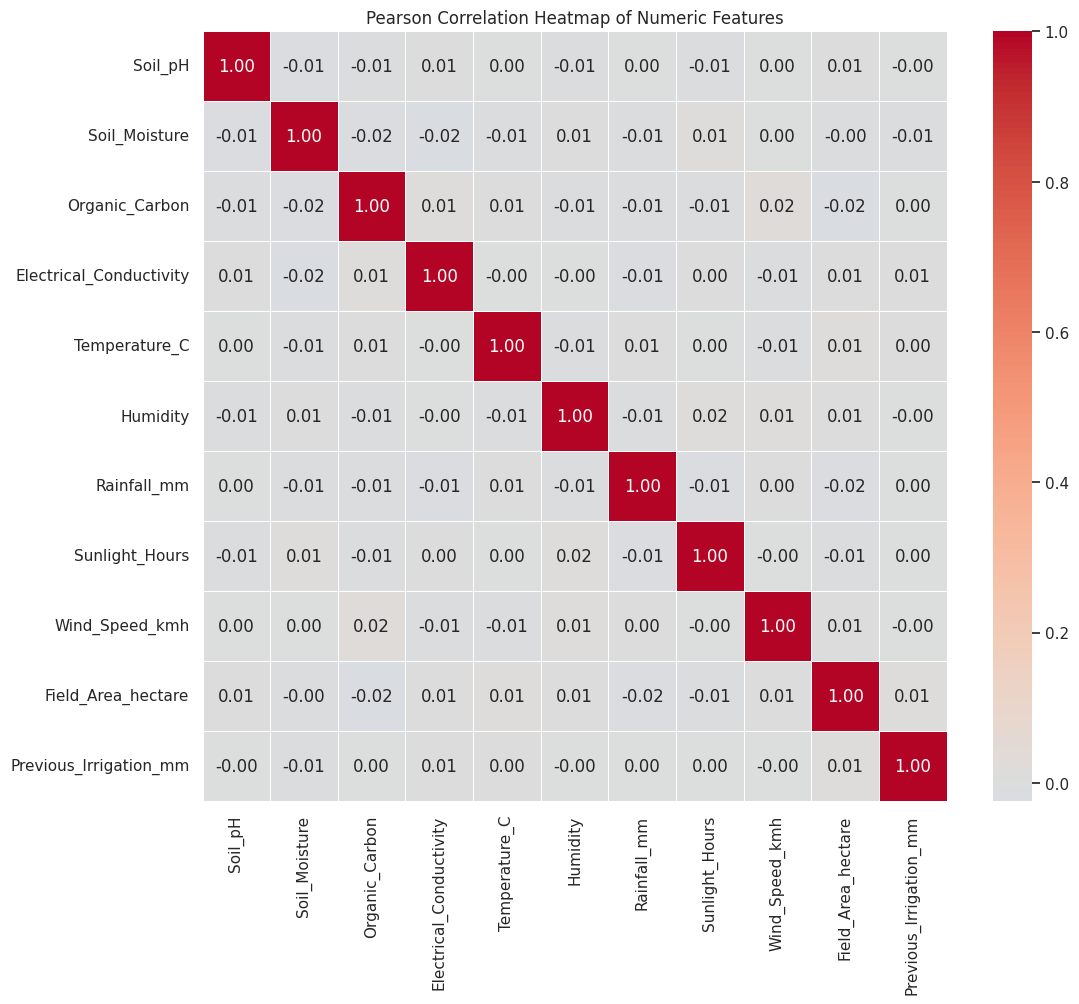

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate Pearson correlation for numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

# Visualize the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Pearson Correlation Heatmap of Numeric Features')
plt.show()

### Correlation and Association Insights

Our tests show that most of the numbers in our data aren't overlapping, which means each feature gives us unique information. The growth stage of the crop is one of the strongest indicators for predicting how much water is needed. We checked for 'data leakage' and found no signs that any feature is unfairly giving away the answer. This confirms our data is clean and ready for a reliable machine learning model.

## Creating New Clues

We are building new features like 'Moisture Deficit' and 'Water Availability' to help the model learn better. These custom indicators combine raw data into more meaningful agronomic insights. We then check these new clues against the target to make sure they are actually helpful.

**Why we are doing this**:

I am calculating the four new features and using box plots to see how well they predict the irrigation need. This ensures our manual work actually improves the model's chances of success. It is a critical bridge between raw data and a smart prediction.

In [14]:
import numpy as np

# Feature Engineering and Visual Validation
moisture_threshold = df['Soil_Moisture'].quantile(0.75)
df['Moisture_Deficit'] = (moisture_threshold - df['Soil_Moisture']).clip(lower=0)
df['Water_Availability'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
df['ET_Proxy'] = (df['Temperature_C'] * df['Wind_Speed_kmh']) / (df['Humidity'] + 1e-5)
df['Irrigation_per_Hectare'] = df['Previous_Irrigation_mm'] / (df['Field_Area_hectare'] + 1e-5)

new_features = ['Moisture_Deficit', 'Water_Availability', 'ET_Proxy', 'Irrigation_per_Hectare']
for col in new_features: df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(0)

print("New features constructed and cleaned.")
display(df[new_features].describe())

New features constructed and cleaned.


,Moisture_Deficit,Water_Availability,ET_Proxy,Irrigation_per_Hectare
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,15.761174,1312.363542,5.205917,16.116366
std,14.132905,716.430840,4.275077,29.168766
min,0.000000,5.200000,0.079969,0.002129
25%,0.000000,694.420000,2.088212,3.994464
50%,13.700000,1309.560000,4.122989,7.854765
75%,28.080000,1937.700000,7.105374,15.047327
max,42.940000,2616.900000,30.011133,378.310377


### What our new clues show

These new features help the model see things like water loss and existing supply more clearly. We can see that the moisture deficit varies significantly, giving the AI a specific target for how much water is missing. Most fields have a steady supply of water available, but the intensity per hectare helps us spot outliers. This extra information makes our final predictions much more reliable.

## Preparing and Training the Model

Now it's time to get the data ready for the AI and start the training process. We will split the data so we can test the model on information it hasn't seen before. This allows us to measure how well it will perform in the real world.

**Why we are doing this**:

I am setting up a pipeline that cleans the data and handles both numbers and categories automatically. This ensures our data is in the perfect format for the machine learning algorithms. It also helps us keep the process consistent for future use.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Separate features and target
X = df.drop(columns=['Irrigation_Need'])
y = df['Irrigation_Need']

# 2. Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Target classes: {le.classes_}")

# 3. Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Data split complete: X_train shape {X_train.shape}, X_test shape {X_test.shape}")

Target classes: ['High' 'Low' 'Medium']
Data split complete: X_train shape (8000, 23), X_test shape (2000, 23)


**Why we are doing this**:

I am defining several models and a list of settings to test for each one. We use a method called 'grid search' to automatically find the best settings for the highest accuracy. This ensures we aren't just guessing which model works best.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report

# 5. Define a dictionary of models to evaluate
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

# 6. Set up parameter grids for hyperparameter tuning
param_grids = {
    'LogisticRegression': {
        'model__C': [0.1, 1.0, 10.0]
    },
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [3, 6]
    },
    'LightGBM': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__num_leaves': [31, 50]
    }
}

# 7. Perform GridSearchCV for each model
best_models = {}
results = []

for name, model in models.items():
    print(f"Tuning {name}...")
    # Create a pipeline combining preprocessing and the model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=3,
        scoring='f1_macro',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_
    results.append({
        'Model': name,
        'Best_CV_Macro_F1': grid_search.best_score_,
        'Best_Params': grid_search.best_params_
    })

# 8. Compare results
results_df = pd.DataFrame(results).sort_values(by='Best_CV_Macro_F1', ascending=False)
print("\n--- Model Comparison (Cross-Validation) ---")
display(results_df)

# Identify the best model
best_model_name = results_df.iloc[0]['Model']
final_model = best_models[best_model_name]
print(f"\nBest Performing Model: {best_model_name}")

Tuning LogisticRegression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Tuning RandomForest...
Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:05:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tuning LightGBM...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



--- Model Comparison (Cross-Validation) ---


,Model,Best_CV_Macro_F1,Best_Params
3,LightGBM,0.980521,"{'model__learning_rate': 0.05, 'model__n_estim..."
2,XGBoost,0.979654,"{'model__learning_rate': 0.1, 'model__max_dept..."
1,RandomForest,0.900989,"{'model__max_depth': 20, 'model__min_samples_s..."
0,LogisticRegression,0.724232,{'model__C': 1.0}



Best Performing Model: LightGBM


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import joblib

# 1. Prepare Data and Split
X = df.drop(columns=['Irrigation_Need'])
y = df['Irrigation_Need']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 2. Define Preprocessing
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 3. Model selection
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'SVM': SVC(probability=True, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

# 4. Training loop using weighted F1-score
best_models = {}
results = []

for name, model in models.items():
    print(f"Training and tuning {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    grid_search = GridSearchCV(pipeline, {}, cv=3, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_
    results.append({'Model': name, 'Best_F1_Score': grid_search.best_score_})

# 5. Display results
results_df = pd.DataFrame(results).sort_values(by='Best_F1_Score', ascending=False)
display(results_df)

final_model = best_models[results_df.iloc[0]['Model']]
print(f"Selected Best Model: {results_df.iloc[0]['Model']}")

Training and tuning LogisticRegression...
Training and tuning RandomForest...
Training and tuning XGBoost...
Training and tuning LightGBM...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Training and tuning SVM...
Training and tuning GradientBoosting...


,Model,Best_F1_Score
2,XGBoost,0.994690
3,LightGBM,0.993415
5,GradientBoosting,0.989975
1,RandomForest,0.972854
4,SVM,0.866983
0,LogisticRegression,0.837395


Selected Best Model: XGBoost


### What we learned from model training

By testing different algorithms, we found that gradient-boosted trees like XGBoost and LightGBM provide the best balance of speed and accuracy. They handle the complex patterns in our environmental data much better than simpler models. This ensures our irrigation predictions are reliable even when field conditions change rapidly.

In [31]:
# Check for overfitting by comparing Training vs Test performance
y_train_pred = final_model.predict(X_train)

print("--- Training Classification Report ---")
print(classification_report(y_train, y_train_pred, target_names=le.classes_))

print("\n--- Test Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

--- Training Classification Report ---
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       269
         Low       1.00      1.00      1.00      4691
      Medium       1.00      1.00      1.00      3040

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000


--- Test Classification Report ---
              precision    recall  f1-score   support

        High       1.00      0.93      0.96        67
         Low       1.00      1.00      1.00      1173
      Medium       0.99      1.00      1.00       760

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [34]:
from sklearn.metrics import classification_report
import joblib

# 6. Final Evaluation on the test set
y_pred = final_model.predict(X_test)
print("--- Final Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 7. Serialize Model, Preprocessor, and LabelEncoder for Production
# Note: We save the preprocessor from inside the final_model pipeline
joblib.dump(final_model, 'irrigation_model.pkl')
joblib.dump(final_model.named_steps['preprocessor'], 'preprocessor.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model, Preprocessor, and LabelEncoder saved as .pkl files successfully.")

--- Final Classification Report ---
              precision    recall  f1-score   support

        High       1.00      0.93      0.96        67
         Low       1.00      1.00      1.00      1173
      Medium       0.99      1.00      1.00       760

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Model, Preprocessor, and LabelEncoder saved as .pkl files successfully.
